# TinyCNN → ONNX: export, run on a folder, compare outputs

Converts the current PyTorch checkpoint to ONNX, runs both the PyTorch model and the ONNX model on the same folder of clips, and compares their outputs clip-by-clip.

Just set the three paths in the config cell and run all cells top to bottom.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import onnx
import onnxruntime as ort
from tqdm.notebook import tqdm

sys.path.append(os.path.abspath(".."))
from aed_inference import load_model, preprocess_clip, find_audio_clips, N_MELS, N_FRAMES


## Config

Set these three paths, then run everything below.

In [2]:
MODEL_PATH = "outputs/models/tinycnn_v3.pth"       # existing .pth checkpoint
ONNX_PATH = "outputs/models/tinycnn_v3.onnx"       # where to write the exported model
CLIPS_FOLDER = "/Volumes/TOSHIBA EXT/Segmented Foldered_sub"            # folder of audio clips to test on


## 1. Load the PyTorch model

Uses your existing `load_model()` so this stays in sync with how `aed_inference.py` actually loads checkpoints.

In [3]:
device = torch.device("cpu")  # cpu is fine here, we're just comparing outputs
pt_model, checkpoint = load_model(MODEL_PATH, device=device)


Using model: tinycnn_v3.pth
  Version/notes:         TinyCNN v3 — 11213 not_meaningful clips (acoustic scan + model_inference_v1 + model_inference_v2)
  Device:                cpu
  Val accuracy:          0.9984
  Not_meaningful recall: 1.000
  Not_meaningful F1:     0.990



## 2. Export to ONNX

The wrapper bakes in `sigmoid()` + the `1 - p` complement, so the ONNX model's output matches `aed_inference.predict()` directly (a `not_meaningful` probability), not the raw logit.

In [5]:
class TinyCNNForExport(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        logit = self.base_model(x)
        not_meaningful_prob = 1.0 - torch.sigmoid(logit)
        return not_meaningful_prob.squeeze(1)


export_model = TinyCNNForExport(pt_model).eval()
dummy_input = torch.randn(1, 1, N_MELS, N_FRAMES, dtype=torch.float32)

os.makedirs(os.path.dirname(ONNX_PATH) or ".", exist_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["mel_spectrogram"],
    output_names=["not_meaningful_prob"],
    dynamic_axes={
        "mel_spectrogram": {0: "batch_size"},
        "not_meaningful_prob": {0: "batch_size"},
    },
)

onnx.checker.check_model(onnx.load(ONNX_PATH))
print(f"Exported and validated: {ONNX_PATH}")


/var/folders/18/gw6v9vc95bg8w0jxzmjwm2br0000gn/T/ipykernel_78287/3877312329.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0804 11:46:53.332000 78287 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0804 11:46:53.903000 78287 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0804 11:46:53

[torch.onnx] Obtain model graph for `TinyCNNForExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyCNNForExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/anaconda3/envs/kwf_aed/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported and validated: outputs/models/tinycnn_v3.onnx


## 3. Load the ONNX Runtime session

In [6]:
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name


## 4. Run both models on every clip in the folder

Same preprocessing (`preprocess_clip`) feeds both models, so any difference in the output comes from the export itself, not from preprocessing drift.

In [7]:
clips_df = find_audio_clips(CLIPS_FOLDER)
print(f"Found {len(clips_df)} clips")

rows = []
for _, row in tqdm(clips_df.iterrows(), total=len(clips_df)):
    path = row["audio_path"]
    try:
        mel = preprocess_clip(path)  # (N_MELS, N_FRAMES)
    except Exception as e:
        print(f"Skipping {row['clip_name']}: {e}")
        continue

    x_torch = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0)  # (1, 1, N_MELS, N_FRAMES)

    with torch.no_grad():
        pt_prob = float(export_model(x_torch).item())

    onnx_prob = float(session.run(None, {input_name: x_torch.numpy()})[0][0])

    rows.append({
        "clip_name": row["clip_name"],
        "pytorch_prob": pt_prob,
        "onnx_prob": onnx_prob,
        "abs_diff": abs(pt_prob - onnx_prob),
    })

compare_df = pd.DataFrame(rows)
compare_df.head()


Found 631317 clips


  0%|          | 0/631317 [00:00<?, ?it/s]

/Users/huyguy/Documents/Documents - Huys MacBook Pro/Job Materials/KwF/Audio Detection/Code/audio-detection-main/aed_inference.py:79: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)
/opt/anaconda3/envs/kwf_aed/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping Audio_Moth_5_20250318_043905.wav: 


,clip_name,pytorch_prob,onnx_prob,abs_diff
0,Audio_Moth_1_20250321_010051.wav,0.0,0.0,0.0
1,Audio_Moth_1_20250321_010118.wav,0.0,0.0,0.0
2,Audio_Moth_1_20250321_010115.wav,0.0,0.0,0.0
3,Audio_Moth_1_20250321_010009.wav,0.0,0.0,0.0
4,Audio_Moth_1_20250321_010006.wav,0.0,0.0,0.0


## 5. Compare outputs

If the export is correct, `abs_diff` should be tiny (floating point noise, typically well under `1e-4`) for every clip.

In [8]:
print(f"Clips compared: {len(compare_df)}")
print(f"Max abs diff:    {compare_df['abs_diff'].max():.3e}")
print(f"Mean abs diff:   {compare_df['abs_diff'].mean():.3e}")

TOLERANCE = 1e-4
mismatches = compare_df[compare_df["abs_diff"] > TOLERANCE]

if len(mismatches) == 0:
    print(f"\nAll clips match within tolerance ({TOLERANCE}). Export looks good.")
else:
    print(f"\n{len(mismatches)} clip(s) exceed tolerance ({TOLERANCE}):")
    display(mismatches)


Clips compared: 631316
Max abs diff:    1.788e-06
Mean abs diff:   3.496e-09

All clips match within tolerance (0.0001). Export looks good.


### Optional: quick visual check of the differences

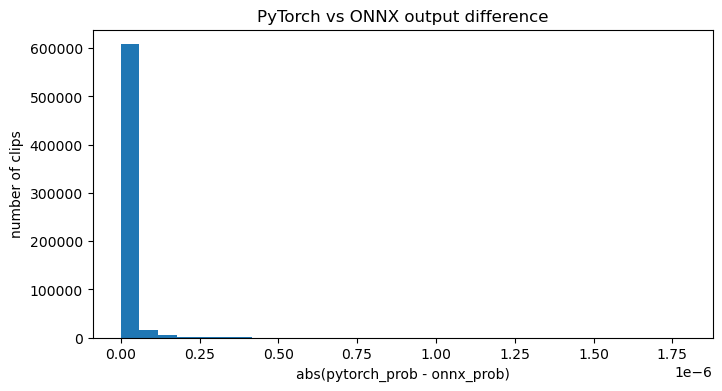

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(compare_df["abs_diff"], bins=30)
plt.xlabel("abs(pytorch_prob - onnx_prob)")
plt.ylabel("number of clips")
plt.title("PyTorch vs ONNX output difference")
plt.show()


## 6. Save the comparison

In [10]:
OUTPUT_CSV = "onnx_vs_pytorch_comparison.csv"
compare_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved comparison to {OUTPUT_CSV}")


Saved comparison to onnx_vs_pytorch_comparison.csv
